# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

Queremos estimar el precio de reventa de un automóvil usado a partir de siete datos que su dueño conoce: año, precio de agencia actual, kilometraje, combustible, tipo de vendedor, transmisión y número de dueños anteriores.

Es un problema de **regresión supervisada**. La variable objetivo es `Selling_Price`, en *lakhs* de rupias indias (1 lakh = 100 000 INR). Hay solo unos 300 autos y unos pocos son muy caros, lo que condiciona la elección del modelo.

# Caso Aplicado: Precio de Reventa de un Automóvil
## Regresión con pocos datos: modelar la razón de reventa y no el precio

---

**Temas:** Variables categóricas · Pipeline · Validación cruzada repetida · Extrapolación de los árboles · Cambio del objetivo  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento y limpieza | ¿Hay filas repetidas, categorías con casi ningún ejemplo y una regularidad que se pueda aprovechar? |
| 2 — Exploración | ¿Qué variables se relacionan con el precio y con la razón de reventa? |
| 3 — Modelo | ¿Mejora modelar la razón reventa / agencia frente a modelar el precio? |
| 4 — Evaluación | ¿Qué pasa con autos más caros que cualquiera del entrenamiento? |

> Nota: con pocos datos, un buen R2 de prueba puede ser un accidente de la partición. Por eso los candidatos se comparan con validación cruzada repetida, y las cifras de la prueba se leen con sus intervalos.

Este notebook es un extra del modelo 02 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto tiene 301 registros y 9 columnas:

- Car_Name      : variable cualitativa nominal, nombre del modelo (se descarta, se explica abajo)
- Year          : variable cuantitativa, año de fabricación
- Selling_Price : variable objetivo, precio de venta en lakhs
- Present_Price : variable cuantitativa, precio de agencia actual en lakhs
- Kms_Driven    : variable cuantitativa, kilometraje recorrido
- Fuel_Type     : variable cualitativa nominal (Petrol, Diesel, CNG)
- Seller_Type   : variable cualitativa nominal (Dealer, Individual)
- Transmission  : variable cualitativa nominal (Manual, Automatic)
- Owner         : variable cuantitativa, dueños anteriores

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_02_autos/` del repositorio. Son 301 filas y 9 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [5]:
print("Cantidad de registros:", len(datos))
print("Valores nulos:", int(datos.isnull().sum().sum()))
print("Filas duplicadas:", int(datos.duplicated().sum()))
print("Nombres de auto distintos:", datos["Car_Name"].nunique(), "en", len(datos), "filas")

Cantidad de registros: 301
Valores nulos: 0
Filas duplicadas: 2
Nombres de auto distintos: 98 en 301 filas


`Car_Name` tiene cerca de 100 valores distintos en 301 filas: con tan pocos ejemplos por nombre no generaliza, así que se descarta. Hay **2 filas duplicadas**. Se quitan **antes** de dividir, para que una copia no caiga en el entrenamiento y la otra en la prueba.

In [6]:
df = datos.drop(columns=["Car_Name"]).drop_duplicates().reset_index(drop=True)
df.columns = [c.lower() for c in df.columns]
print("Quedan", len(df), "autos")
print("Combustible:", df["fuel_type"].value_counts().to_dict())
print("Dueños anteriores:", df["owner"].value_counts().sort_index().to_dict())
df.head()

Quedan 299 autos
Combustible: {'Petrol': 239, 'Diesel': 58, 'CNG': 2}
Dueños anteriores: {0: 288, 1: 10, 3: 1}


,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Hay categorías casi sin ejemplos: **2 autos de gas natural (CNG)** y **un solo auto con 3 dueños**. El modelo no puede aprender nada fiable de ellos, y la API del proyecto avisa cuando se pregunta por esos casos.

### Una regularidad que se puede aprovechar

Veamos la razón entre el precio de reventa y el de agencia.

In [7]:
razon = df["selling_price"] / df["present_price"]
print("Razón reventa / agencia: mínimo %.2f, mediana %.2f, máximo %.2f" % (razon.min(), razon.median(), razon.max()))
print("Razón mediana por año:", razon.groupby(df["year"]).median().round(2).to_dict())

Razón reventa / agencia: mínimo 0.11, mediana 0.65, máximo 0.99
Razón mediana por año: {2003: 0.22, 2004: 0.12, 2005: 0.26, 2006: 0.19, 2007: 0.24, 2008: 0.27, 2009: 0.3, 2010: 0.38, 2011: 0.48, 2012: 0.49, 2013: 0.54, 2014: 0.61, 2015: 0.72, 2016: 0.8, 2017: 0.91, 2018: 0.94}


La razón **nunca supera 1** y sube de forma regular con el año: un auto de 2003 vale alrededor de una quinta parte de su precio de agencia, y uno de 2017 casi el 90 %. Más adelante se usa esto para elegir qué predecir.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

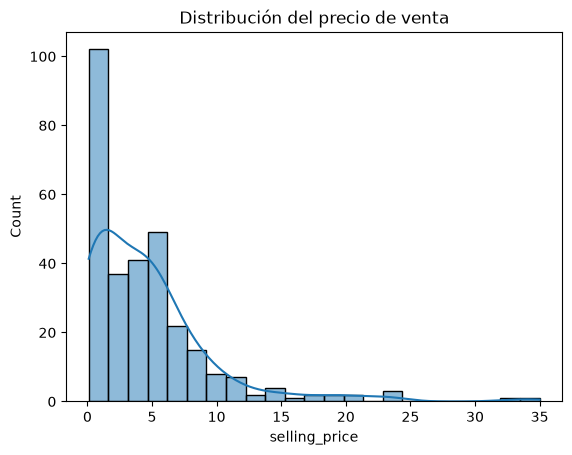

Asimetría: 2.54   Media: 4.59   Mediana: 3.51   Máximo: 35.00


In [8]:
OBJETIVO = "selling_price"
NUMERICAS = ["year", "present_price", "kms_driven", "owner"]
CATEGORICAS = ["fuel_type", "seller_type", "transmission"]
VARIABLES = NUMERICAS + CATEGORICAS

sns.histplot(df[OBJETIVO], kde=True)
plt.title("Distribución del precio de venta")
plt.show()
print("Asimetría: %.2f   Media: %.2f   Mediana: %.2f   Máximo: %.2f" % (df[OBJETIVO].skew(), df[OBJETIVO].mean(), df[OBJETIVO].median(), df[OBJETIVO].max()))

La distribución tiene una asimetría positiva marcada: la mayoría de los autos cuesta poco y unos pocos llegan a precios muy altos.

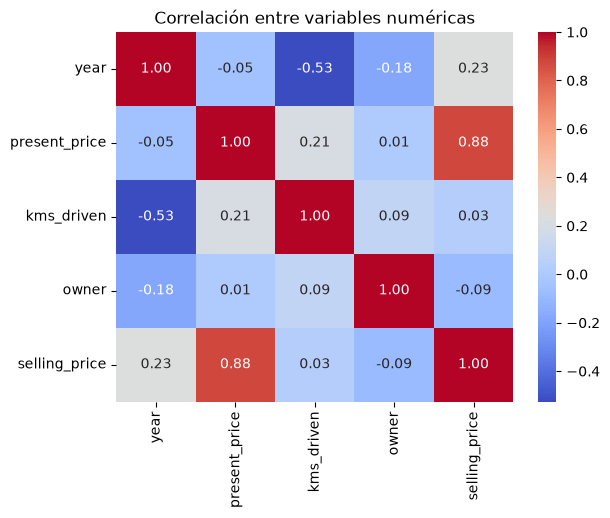

Correlación del kilometraje con el año: -0.53


In [9]:
sns.heatmap(df[NUMERICAS + [OBJETIVO]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()
print("Correlación del kilometraje con el año: %.2f" % df["kms_driven"].corr(df["year"]))

El precio de agencia es, con mucha ventaja, la variable más asociada al precio de reventa. El kilometraje casi no se asocia por sí solo, porque va mezclado con la antigüedad.

> Analogía: el precio de agencia es como el precio de lista de un auto nuevo. Un auto usado vale una fracción de ese precio, y esa fracción depende sobre todo de la edad.

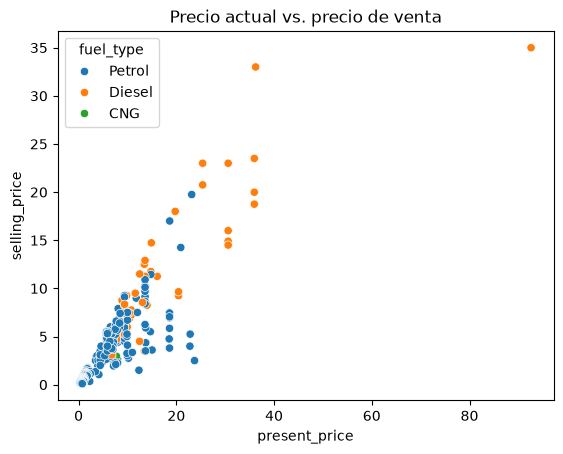

,selling_price,present_price
fuel_type,,
CNG,3.10,6.42
Diesel,7.60,10.38
Petrol,2.65,4.60


In [10]:
sns.scatterplot(data=df, x="present_price", y=OBJETIVO, hue="fuel_type")
plt.title("Precio actual vs. precio de venta")
plt.show()
df.groupby("fuel_type")[[OBJETIVO, "present_price"]].median().round(2)

La relación es aproximadamente lineal, con más dispersión en los autos caros. Los diésel tienen una reventa mediana mayor, pero también un precio de agencia mayor.

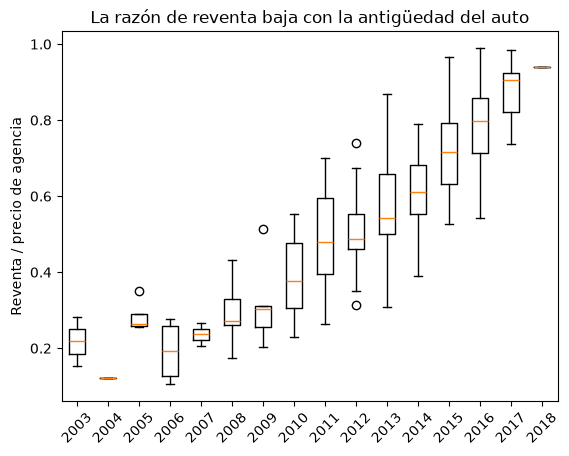

Autos con precio de agencia mayor a 30: 9 | precio de agencia máximo: 92.6


In [11]:
razones = razon.groupby(df["year"])
plt.boxplot([g.to_numpy() for _, g in razones], tick_labels=[str(a) for a, _ in razones])
plt.xticks(rotation=45)
plt.ylabel("Reventa / precio de agencia")
plt.title("La razón de reventa baja con la antigüedad del auto")
plt.show()
print("Autos con precio de agencia mayor a 30:", int((df["present_price"] > 30).sum()), "| precio de agencia máximo:", df["present_price"].max())

Hay un auto de 92.6 lakhs de agencia (un Land Cruiser) y 9 que pasan de 30. Son valores posibles y se conservan, pero ponen a prueba a cualquier modelo que no pueda extrapolar.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

Se separa el 20 % de los autos para la prueba.

In [12]:
X, y = df[VARIABLES], df[OBJETIVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (239, 7)  Prueba: (60, 7)


> Es importante siempre validar los rangos de los conjuntos creados, para evitar caer en extrapolación:

In [13]:
pd.DataFrame({"entrenamiento_max": X_train[NUMERICAS].max(), "prueba_max": X_test[NUMERICAS].max()})

,entrenamiento_max,prueba_max
year,2017.0,2018.00
present_price,92.6,36.23
kms_driven,213000.0,500000.00
owner,1.0,3.00


### Dos formas de predecir

1. **El precio** directamente.
2. **La razón** reventa / agencia, y luego el precio = razón por el precio de agencia.

Un árbol de decisión es constante por tramos: **nunca predice por encima del mayor valor que vio**. Si se entrena con el precio, no puede estimar un auto más caro que los del entrenamiento. La razón, en cambio, es una cantidad acotada, casi independiente de la escala del auto.

La clase `RazonAlPrecioActual` envuelve a cualquier modelo para que aprenda la razón (o su logaritmo).

In [14]:
class RazonAlPrecioActual(BaseEstimator, RegressorMixin):
    def __init__(self, modelo, log=False):
        self.modelo = modelo
        self.log = log

    def fit(self, X, y):
        razon = np.asarray(y, dtype=float) / X["present_price"].to_numpy(dtype=float)
        self.modelo_ = clone(self.modelo).fit(X, np.log(razon) if self.log else razon)
        return self

    def predict(self, X):
        razon = self.modelo_.predict(X)
        return (np.exp(razon) if self.log else razon) * X["present_price"].to_numpy(dtype=float)

### Candidatos

Hay dos **líneas base** (el precio medio y la regla "vale la razón mediana de su precio de agencia") y seis modelos. Cada uno es un `Pipeline` que incluye su preprocesamiento. La selección usa **solo el entrenamiento**, con validación cruzada repetida (5 particiones por 3 repeticiones) y el RMSE en lakhs.

In [15]:
def armar(estimador):
    pre = ColumnTransformer([("num", StandardScaler(), NUMERICAS), ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS)])
    return Pipeline([("preprocesador", pre), ("modelo", estimador)])

bosque = lambda: RandomForestRegressor(n_estimators=200, random_state=SEMILLA, n_jobs=-1)
boosting = lambda: HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, early_stopping=False, random_state=SEMILLA)

def candidatos():
    return {
        "precio medio (línea base)": armar(DummyRegressor(strategy="mean")),
        "regla de depreciación (línea base)": RazonAlPrecioActual(armar(DummyRegressor(strategy="median"))),
        "regresión lineal": armar(LinearRegression()),
        "random forest": armar(bosque()),
        "gradient boosting": armar(boosting()),
        "random forest (razón)": RazonAlPrecioActual(armar(bosque())),
        "gradient boosting (razón)": RazonAlPrecioActual(armar(boosting())),
        "regresión lineal (log-razón)": RazonAlPrecioActual(armar(LinearRegression()), log=True),
    }

validacion = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)
filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, X_train, y_train, cv=validacion, scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"})
    filas[nombre] = {"RMSE cv": -r["test_rmse"].mean(), "desviación": r["test_rmse"].std(), "R2 cv": r["test_r2"].mean()}
comparacion = pd.DataFrame(filas).T.round(3)
comparacion

,RMSE cv,desviación,R2 cv
precio medio (línea base),4.887,0.844,-0.010
regla de depreciación (línea base),2.363,0.856,0.754
regresión lineal,1.731,0.395,0.872
random forest,1.507,0.894,0.892
gradient boosting,2.125,0.857,0.807
random forest (razón),0.792,0.176,0.971
gradient boosting (razón),0.823,0.165,0.970
regresión lineal (log-razón),1.156,0.750,0.937


Modelar la razón **reduce casi a la mitad el error** del bosque en niveles y, sobre todo, **estabiliza** el resultado: la desviación entre particiones baja mucho, porque en niveles el error depende de que un auto muy caro caiga en el pliegue de validación. Los dos modelos de razón con árboles no se distinguen entre sí.

In [16]:
es_base = lambda nombre: "línea base" in nombre
ganador = comparacion[[not es_base(n) for n in comparacion.index]]["RMSE cv"].idxmin()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(X_train, y_train)

Modelo elegido: random forest (razón)


##### Evaluación en el conjunto de prueba

In [17]:
def metricas(real, pred):
    return {"R2": r2_score(real, pred), "MAE": mean_absolute_error(real, pred), "RMSE": np.sqrt(mean_squared_error(real, pred))}

prueba = {n: metricas(y_test, p.fit(X_train, y_train).predict(X_test)) for n, p in candidatos().items()}
pd.DataFrame(prueba).T.round(3)

,R2,MAE,RMSE
precio medio (línea base),-0.000,3.327,5.077
regla de depreciación (línea base),0.554,1.811,3.389
regresión lineal,0.753,1.473,2.524
random forest,0.501,1.502,3.587
gradient boosting,0.695,1.381,2.805
random forest (razón),0.954,0.697,1.086
gradient boosting (razón),0.965,0.589,0.950
regresión lineal (log-razón),0.963,0.603,0.973


El bosque en niveles saca un R2 de prueba mucho menor que el de su validación cruzada. No es un fallo de la prueba sino de ese modelo, que no extrapola. Con **60 autos** de prueba, y **uno solo** de más de 15 lakhs, cualquier cifra es ruidosa. Por eso se calcula un intervalo de confianza.

IC 95 % del RMSE: [0.793, 1.342]


IC 95 % del R2:   [0.87, 0.981]


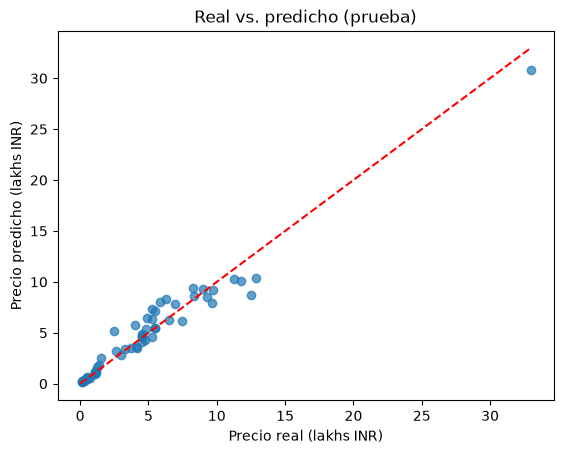

In [18]:
def intervalo_bootstrap(y, p, funcion, remuestreos=1000, semilla=42):
    rng = np.random.default_rng(semilla)
    valores = []
    while len(valores) < remuestreos:
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1:
            valores.append(funcion(y[i], p[i]))
    return [round(float(np.percentile(valores, 2.5)), 3), round(float(np.percentile(valores, 97.5)), 3)]

y_real, y_pred = np.asarray(y_test), modelo.predict(X_test)
print("IC 95 % del RMSE:", intervalo_bootstrap(y_real, y_pred, lambda a, b: float(np.sqrt(mean_squared_error(a, b)))))
print("IC 95 % del R2:  ", intervalo_bootstrap(y_real, y_pred, lambda a, b: float(r2_score(a, b))))

plt.scatter(y_test, y_pred, alpha=0.7)
limite = max(y_test.max(), y_pred.max())
plt.plot([0, limite], [0, limite], "r--")
plt.xlabel("Precio real (lakhs INR)")
plt.ylabel("Precio predicho (lakhs INR)")
plt.title("Real vs. predicho (prueba)")
plt.show()

### Experimento: autos más caros que los del entrenamiento

Se entrena solo con los autos de precio de agencia de 15 lakhs o menos y se prueba con los más caros.

In [19]:
barato = df["present_price"] <= 15
filas = {"autos de entrenamiento": int(barato.sum()), "autos caros de prueba": int((~barato).sum())}
resultados = {}
for nombre in ("random forest", ganador):
    ajustado = candidatos()[nombre].fit(df[barato][VARIABLES], df[barato][OBJETIVO])
    pred, real = ajustado.predict(df[~barato][VARIABLES]), df[~barato][OBJETIVO]
    resultados[nombre] = {"RMSE": np.sqrt(mean_squared_error(real, pred)), "sesgo (predicho - real)": (pred - real).mean()}
print(filas)
pd.DataFrame(resultados).T.round(2)

{'autos de entrenamiento': 271, 'autos caros de prueba': 28}


,RMSE,sesgo (predicho - real)
random forest,8.98,-5.8
random forest (razón),2.05,0.3


El bosque en niveles **subestima en promedio casi 6 lakhs** a los autos caros, porque no puede predecir más allá de lo que vio. El modelo de razón casi no tiene sesgo. Por eso la API puede estimar con sentido un auto de 90 lakhs de agencia.

### Modelo para servir y predicción

Con tan pocos datos, el modelo que se usa en la aplicación se reentrena con **todos** los autos.

In [20]:
final = candidatos()[ganador].fit(X, y)
auto = pd.DataFrame([{"year": 2016, "present_price": 8.5, "kms_driven": 30000, "owner": 0,
                      "fuel_type": "Petrol", "seller_type": "Dealer", "transmission": "Manual"}])
valor = final.predict(auto[VARIABLES])[0]
print("Precio de reventa estimado: %.2f lakhs (unas %d rupias), %d %% del precio de agencia" % (valor, round(valor * 100_000), round(100 * valor / 8.5)))

Precio de reventa estimado: 6.40 lakhs (unas 639840 rupias), 75 % del precio de agencia


---
# Conclusiones
---

## Resultados

Con siete datos básicos del auto se puede estimar su precio de reventa con un error medio de unos 0.7 lakhs, frente a más de 3 al predecir el precio medio. El hallazgo principal es de modelado: **cambiar el objetivo de precio a razón** (reventa / agencia) casi duplica la precisión, estabiliza el resultado y permite estimar autos más caros que cualquiera del entrenamiento.

El hallazgo metodológico es que un R2 de prueba alto puede ser un accidente de la partición: con pocos datos hay que comparar todos los candidatos con la misma validación cruzada repetida y leer la prueba con su intervalo.

Limitaciones: son unos 300 autos de un solo mercado (India, 2003 a 2018). Los autos de gas natural y con tres dueños casi no tienen ejemplos. Con 60 autos de prueba las métricas son ruidosas, y las diferencias entre Random Forest y Gradient Boosting de razón no son concluyentes.

### Referencias

> Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.
> Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, 29(5), 1189-1232.
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer.